<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #16a34a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Ensamble por Bagging y Bootstrap Aggregation 🎒🎲
      </h1>
      <p style="margin: 6px 0 0 0; color: #16a34a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Bagging & Bootstrap Aggregating
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #15803d; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #16a34a; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/03_Ensamble_por_Bagging_y_Bootstrap.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Otra estrategia frente a la misma varianza: promediar en lugar de restringir 📈

El **Cuaderno 02** atacó la alta varianza de los árboles de decisión (demostrada en el Cuaderno 00: sin restricciones, train=1.0000, test=0.6928) **restringiendo un único árbol** — con pre-poda o post-poda — hasta encontrar un punto de equilibrio entre sesgo y varianza. Este cuaderno ataca el mismo problema desde un ángulo completamente distinto: en lugar de simplificar un árbol para que tenga menos varianza, se entrenan **muchos árboles complejos** (cada uno sin podar, con varianza alta) sobre versiones ligeramente distintas de los datos, y se **promedian** sus predicciones.

La justificación es estadística y no depende del algoritmo específico (aplica a cualquier modelo de alta varianza): si se promedian $B$ predictores cuyos errores son razonablemente independientes entre sí, la varianza del promedio cae en un factor cercano a $1/B$ mientras que el sesgo se mantiene aproximadamente igual al de un predictor individual — la misma descomposición sesgo-varianza que el Módulo 02 de este curso presentó para explicar el error de generalización de un modelo. Los árboles de decisión son el caso ideal para aplicar esta idea: son modelos de **sesgo bajo** (pueden ajustar relaciones complejas) pero **varianza alta** (el Cuaderno 00 lo demostró entrenando árboles sobre distintas muestras bootstrap de los mismos datos), justo la combinación que más se beneficia de promediar.

### 1.1 Preparación: recargando los datos y la partición

Se repite exactamente la misma codificación de variables y la misma partición train/test (`test_size=0.25`, `random_state=42`, estratificada por `churn`) usadas en los Cuadernos 00, 01 y 02, para que los resultados de este cuaderno sean directamente comparables.

In [25]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "abandono_clientes_telecom.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df_telecom = pd.read_csv(load_dataset("abandono_clientes_telecom.csv"))

df_prep = df_telecom.copy()
df_prep["factura_electronica"] = df_prep["factura_electronica"].map({"No": 0, "Si": 1})

orden_contrato = [["Mes_a_Mes", "Un_Ano", "Dos_Anos"]]
encoder_contrato = OrdinalEncoder(categories=orden_contrato)
df_prep["tipo_contrato_ord"] = encoder_contrato.fit_transform(df_prep[["tipo_contrato"]]).astype(int)

soporte_dummies = pd.get_dummies(df_prep["soporte_tecnico"], prefix="soporte").astype(int)
df_prep = pd.concat([df_prep, soporte_dummies], axis=1)

feature_cols = ["antiguedad_meses", "cargo_mensual", "cargos_totales",
                 "tipo_contrato_ord", "factura_electronica",
                 "soporte_No", "soporte_Si", "soporte_Sin_Internet"]

X = df_prep[feature_cols]
y = df_prep["churn"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Filas de entrenamiento: {len(Xtr)}  |  Filas de prueba: {len(Xte)}")

Filas de entrenamiento: 1875  |  Filas de prueba: 625


---
## 2. Muestreo Bootstrap: la materia prima del Bagging 🎲

Un **muestreo bootstrap** consiste en construir una nueva muestra del mismo tamaño que el conjunto original, seleccionando observaciones **al azar y con reemplazo** (cada observación puede aparecer 0, 1 o varias veces en la muestra resultante). Es la técnica que ya se usó en el Cuaderno 00 (Sección 8) para demostrar la inestabilidad de los árboles; aquí se formaliza y se cuantifica.

**Pregunta clave:** si se toma una muestra bootstrap de tamaño $n$ a partir de $n$ observaciones originales, ¿qué fracción de las observaciones originales queda **fuera** de la muestra? La probabilidad de que una observación específica **no** sea elegida en un sorteo es $1 - 1/n$; como se hacen $n$ sorteos independientes (con reemplazo), la probabilidad de que quede completamente fuera de la muestra bootstrap es $(1 - 1/n)^n$, que converge rápidamente a $e^{-1} \approx 0.3679$ a medida que $n$ crece. En otras palabras: **cada muestra bootstrap típicamente contiene solo ~63.2% de las observaciones originales** (algunas repetidas), dejando fuera **~36.8%** — el fundamento de la estimación Out-of-Bag de la Sección 4.

In [26]:
rng = np.random.RandomState(42)
n = len(Xtr)
print(f"Filas en el conjunto de entrenamiento: {n}\n")

for i in range(3):
    idx = rng.choice(n, size=n, replace=True)
    n_unicas = len(np.unique(idx))
    print(f"Muestra bootstrap {i}: {n_unicas} filas originales unicas incluidas ({n_unicas/n*100:.2f}%)  "
          f"|  {n - n_unicas} filas nunca elegidas ({(n - n_unicas)/n*100:.2f}%)  "
          f"|  repeticiones maximas de una misma fila: {pd.Series(idx).value_counts().max()}")

Filas en el conjunto de entrenamiento: 1875

Muestra bootstrap 0: 1160 filas originales unicas incluidas (61.87%)  |  715 filas nunca elegidas (38.13%)  |  repeticiones maximas de una misma fila: 5
Muestra bootstrap 1: 1143 filas originales unicas incluidas (60.96%)  |  732 filas nunca elegidas (39.04%)  |  repeticiones maximas de una misma fila: 6
Muestra bootstrap 2: 1184 filas originales unicas incluidas (63.15%)  |  691 filas nunca elegidas (36.85%)  |  repeticiones maximas de una misma fila: 5


In [27]:
rng2 = np.random.RandomState(0)
fracciones_incluidas = [len(np.unique(rng2.choice(n, size=n, replace=True))) / n for _ in range(200)]
fracciones_incluidas = np.array(fracciones_incluidas)

print(f"Promedio empirico de inclusion sobre 200 muestras bootstrap: {fracciones_incluidas.mean()*100:.2f}%")
print(f"Valor teorico (1 - 1/e): {(1 - 1/np.e)*100:.2f}%")
print(f"\nPromedio empirico de exclusion (filas 'Out-of-Bag'): {(1 - fracciones_incluidas.mean())*100:.2f}%")
print(f"Valor teorico (1/e): {(1/np.e)*100:.2f}%")

Promedio empirico de inclusion sobre 200 muestras bootstrap: 63.24%
Valor teorico (1 - 1/e): 63.21%

Promedio empirico de exclusion (filas 'Out-of-Bag'): 36.76%
Valor teorico (1/e): 36.79%


**Resultado:** sobre los 1875 clientes del conjunto de entrenamiento, el promedio empírico de inclusión (**63.24%**) coincide casi exactamente con el valor teórico $1 - 1/e = 63.21\%$, y el promedio de exclusión (**36.76%**) coincide con $1/e = 36.79\%$ — la aproximación asintótica ya es prácticamente exacta con $n=1875$. Esas filas excluidas de cada muestra bootstrap —aproximadamente 1 de cada 3 clientes, distintas en cada muestra— son las que la Sección 4 aprovecha como conjunto de validación gratuito (**Out-of-Bag**) para cada árbol individual.

---
## 3. El algoritmo de Bagging (*Bootstrap Aggregating*) 🎒

**Bagging**, propuesto por Breiman (1996), aplica la idea de la Sección 1 de forma directa:

```
para b = 1, 2, ..., B:
    tomar una muestra bootstrap (con reemplazo, tamano n) del conjunto de entrenamiento
    entrenar un arbol de decision SIN restricciones sobre esa muestra  ->  arbol_b

prediccion final:
    clasificacion: voto mayoritario entre los B arboles
    regresion:     promedio de las B predicciones
```

Cada `arbol_b` se entrena deliberadamente **sin poda** (los árboles individuales conservan su varianza alta) porque es precisamente esa varianza, cancelada por el promedio de muchos árboles distintos, lo que produce la mejora — podar los árboles individuales antes de promediarlos reduciría también su diversidad, que es lo que hace útil al promedio. `abandono_clientes_telecom.csv` es un problema de **clasificación**, así que la agregación es por voto mayoritario; `BaggingClassifier` de `scikit-learn` implementa exactamente este procedimiento.

In [28]:
arbol_completo = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
arbol_pre_podado = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xtr, ytr)
arbol_post_podado = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0017782004989982565).fit(Xtr, ytr)

bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50,
                             oob_score=True, random_state=42)
bagging.fit(Xtr, ytr)

print("Comparacion de exactitud (train / test):")
print(f"  Arbol SIN restricciones (Cuaderno 00)       -> train={arbol_completo.score(Xtr, ytr):.4f}  test={arbol_completo.score(Xte, yte):.4f}")
print(f"  Mejor pre-podado, max_depth=4 (Cuaderno 02)  -> train={arbol_pre_podado.score(Xtr, ytr):.4f}  test={arbol_pre_podado.score(Xte, yte):.4f}")
print(f"  Mejor post-podado, ccp_alpha (Cuaderno 02)   -> train={arbol_post_podado.score(Xtr, ytr):.4f}  test={arbol_post_podado.score(Xte, yte):.4f}")
print(f"  Bagging, 50 arboles sin podar                -> train={bagging.score(Xtr, ytr):.4f}  test={bagging.score(Xte, yte):.4f}")

Comparacion de exactitud (train / test):
  Arbol SIN restricciones (Cuaderno 00)       -> train=1.0000  test=0.6928
  Mejor pre-podado, max_depth=4 (Cuaderno 02)  -> train=0.7509  test=0.7600
  Mejor post-podado, ccp_alpha (Cuaderno 02)   -> train=0.7616  test=0.7584
  Bagging, 50 arboles sin podar                -> train=1.0000  test=0.7216


**Lectura:** Bagging reduce drásticamente el sobreajuste del árbol individual sin restricciones — su exactitud de prueba sube de **0.6928** a **0.7216**, una mejora de más de 2.8 puntos porcentuales lograda sin podar ni un solo árbol, solo promediando 50 de ellos — pero **no logra superar** a los árboles cuidadosamente podados del Cuaderno 02 (pre-podado: 0.7600; post-podado: 0.7584). Nótese además que la exactitud de **entrenamiento** de Bagging sigue siendo perfecta (1.0000, igual que el árbol individual sin restricciones) — cada árbol dentro del ensamble sigue memorizando su propia muestra bootstrap; lo que cambia es que, al promediar 50 memorias distintas y parcialmente independientes, el ensamble generaliza mejor que cualquiera de ellas por separado. La Sección 6 explica por qué Bagging no alcanza aquí el desempeño de la mejor poda: los árboles del ensamble resultan menos independientes entre sí de lo que la teoría de la Sección 1 idealiza.

---
## 4. Estimación Out-of-Bag (OOB): validación gratuita 🆓

La Sección 2 mostró que cada muestra bootstrap deja fuera, en promedio, un **36.8%** de las observaciones originales. Esas observaciones —distintas para cada árbol del ensamble— nunca participaron en el entrenamiento de `arbol_b`, así que pueden usarse para **evaluarlo** exactamente como si fueran un conjunto de prueba independiente, sin gastar ni una fila del dataset original en una partición separada. Promediando esta evaluación sobre todos los árboles (cada observación se evalúa solo con los árboles para los que fue Out-of-Bag) se obtiene el **OOB score**: una estimación de la exactitud de generalización del ensamble completo, calculada usando únicamente los datos de entrenamiento. `BaggingClassifier(oob_score=True)` la calcula automáticamente durante el ajuste.

In [29]:
print(f"OOB score del ensamble (50 arboles): {bagging.oob_score_:.4f}")
print(f"Exactitud sobre el conjunto de prueba real (Xte, yte): {bagging.score(Xte, yte):.4f}")
print(f"Diferencia absoluta: {abs(bagging.oob_score_ - bagging.score(Xte, yte)):.4f}")

OOB score del ensamble (50 arboles): 0.7136
Exactitud sobre el conjunto de prueba real (Xte, yte): 0.7216
Diferencia absoluta: 0.0080


**Lectura:** el OOB score (**0.7136**) y la exactitud sobre el conjunto de prueba real (**0.7216**) difieren en apenas **0.0080** — una diferencia mínima, dentro del ruido esperable entre dos estimaciones calculadas sobre subconjuntos distintos de datos. Esto confirma que el mecanismo Out-of-Bag funciona como se espera: aunque nunca se usó `Xte, yte` para calcularlo, el OOB score predice con precisión razonable el desempeño real sobre datos nunca vistos. En la práctica, esto tiene una implicación útil: **cuando se usa Bagging (o Bosques Aleatorios, Cuaderno 04), el OOB score puede sustituir a una partición train/test separada** para ajustar hiperparámetros, liberando esas observaciones para el entrenamiento — especialmente valioso en datasets pequeños, aunque no es la limitación de este dataset de 2500 filas.

---
## 5. El efecto del número de árboles (`n_estimators`) 📉

La Sección 1 justificó Bagging con un argumento asintótico: la varianza del promedio cae en un factor cercano a $1/B$ conforme $B$ (`n_estimators`) crece. Esa reducción, sin embargo, tiene **rendimientos decrecientes**: pasar de 10 a 20 árboles reduce la varianza mucho más que pasar de 200 a 300, porque $1/B$ decrece cada vez más lento. La siguiente celda entrena ensambles con distintos valores de `n_estimators` y registra tanto la exactitud de prueba como el OOB score de cada uno, para verificar esta forma de curva sobre datos reales.

In [30]:
n_estimators_grid = [10, 20, 30, 50, 75, 100, 150, 200, 300]
test_accs_bag, oob_scores_bag = [], []

for ne in n_estimators_grid:
    b = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=ne,
                           oob_score=True, random_state=42)
    b.fit(Xtr, ytr)
    test_accs_bag.append(b.score(Xte, yte))
    oob_scores_bag.append(b.oob_score_)
    print(f"n_estimators={ne:<4d}  test_acc={test_accs_bag[-1]:.4f}  oob_score={oob_scores_bag[-1]:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


n_estimators=10    test_acc=0.7264  oob_score=0.6997
n_estimators=20    test_acc=0.7232  oob_score=0.7163
n_estimators=30    test_acc=0.7184  oob_score=0.7147
n_estimators=50    test_acc=0.7216  oob_score=0.7136
n_estimators=75    test_acc=0.7248  oob_score=0.7221
n_estimators=100   test_acc=0.7200  oob_score=0.7280
n_estimators=150   test_acc=0.7232  oob_score=0.7211
n_estimators=200   test_acc=0.7216  oob_score=0.7227
n_estimators=300   test_acc=0.7232  oob_score=0.7227


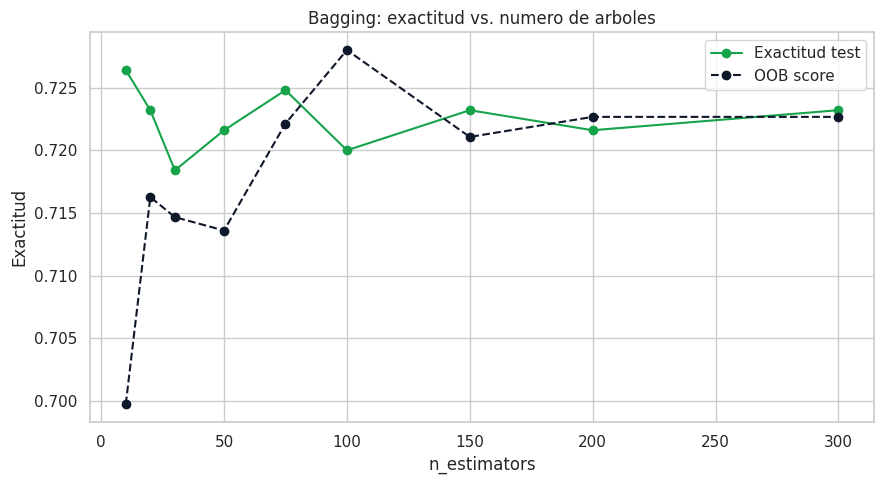

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_estimators_grid, test_accs_bag, marker="o", label="Exactitud test", color="#16a34a")
ax.plot(n_estimators_grid, oob_scores_bag, marker="o", label="OOB score", color="#0f172a", linestyle="--")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Exactitud")
ax.set_title("Bagging: exactitud vs. numero de arboles")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** ambas curvas suben rápido entre 10 y 30 árboles (el OOB score pasa de 0.6997 a 0.7147) y luego se estabilizan, oscilando en una banda estrecha entre aproximadamente 0.715 y 0.728 desde `n_estimators=50` en adelante — añadir de 100 a 300 árboles no produce una mejora sistemática, solo pequeñas fluctuaciones de menos de un punto porcentual atribuibles al azar de qué árboles específicos se agregan. Es exactamente el patrón de rendimientos decrecientes previsto en la Sección 1: los primeros árboles reducen mucho la varianza del ensamble; los siguientes aportan cada vez menos. En la práctica esto significa que, más allá de un umbral relativamente bajo (aquí, unos 50-75 árboles), **aumentar `n_estimators` deja de mejorar la exactitud** y solo incrementa el costo computacional — el techo de desempeño (~0.72) lo determinan otros factores, explorados en la Sección 6.

---
## 6. La limitación honesta de Bagging: árboles poco decorrelacionados 🔗

La Sección 5 mostró que Bagging se estanca alrededor de 0.72 de exactitud de prueba, sin importar cuántos árboles se agreguen — muy por debajo de la mejor poda del Cuaderno 02 (0.7600). La justificación teórica de la Sección 1 (varianza cae en $1/B$) asume implícitamente que los árboles del ensamble son **independientes** o, al menos, poco correlacionados entre sí. Si en cambio todos los árboles tienden a cometer los **mismos** errores —porque todos encuentran la misma estructura dominante en los datos, sin importar qué muestra bootstrap les tocó—, promediarlos aporta mucho menos de lo que la teoría asintótica promete: promediar $B$ copias altamente correlacionadas de la misma predicción no reduce la varianza casi nada, sin importar qué tan grande sea $B$.

`abandono_clientes_telecom.csv` es un caso claro de este problema: `tipo_contrato_ord` es, con diferencia, la variable más informativa (Cuaderno 00: importancia 0.4790, muy por delante de la siguiente). Como CART evalúa **todas** las variables en cada división, prácticamente cualquier muestra bootstrap —sin importar qué filas específicas contenga— va a preferir dividir primero sobre `tipo_contrato_ord` en la raíz. La siguiente celda lo verifica directamente.

In [32]:
raices = []
for i in range(30):
    idx = rng.choice(n, size=n, replace=True)
    Xb, yb = Xtr.iloc[idx], ytr.iloc[idx]
    t = DecisionTreeClassifier(random_state=42).fit(Xb, yb)
    raices.append(feature_cols[t.tree_.feature[0]])

print("Variable elegida en la raiz, en 30 arboles adicionales sobre distintas muestras bootstrap:")
print(Counter(raices))

raices_bagging = [feature_cols[est.tree_.feature[0]] for est in bagging.estimators_]
print("\nMisma verificacion sobre los 50 arboles del ensamble 'bagging' ya entrenado:")
print(Counter(raices_bagging))

preds_arboles = np.array([est.predict(Xte.values) for est in bagging.estimators_])
correlaciones = np.corrcoef(preds_arboles)
iu = np.triu_indices_from(correlaciones, k=1)
print(f"\nCorrelacion promedio entre predicciones de pares de arboles del ensamble: {correlaciones[iu].mean():.4f}")

Variable elegida en la raiz, en 30 arboles adicionales sobre distintas muestras bootstrap:
Counter({'tipo_contrato_ord': 30})

Misma verificacion sobre los 50 arboles del ensamble 'bagging' ya entrenado:
Counter({'tipo_contrato_ord': 50})

Correlacion promedio entre predicciones de pares de arboles del ensamble: 0.3073


**Lectura:** las 30 muestras bootstrap adicionales, igual que los 50 árboles ya entrenados dentro de `bagging`, coinciden **el 100% de las veces** en usar `tipo_contrato_ord` como variable de la raíz — ni una sola muestra bootstrap, por distinta que sea en sus filas específicas, cambia esa decisión. Los árboles del ensamble sí difieren más adelante (en los niveles inferiores, donde el efecto de qué filas exactas contiene cada muestra pesa más, como ya mostró el Cuaderno 00), y por eso Bagging **sí** mejora sobre un único árbol sin restricciones (0.6928 → 0.7216) — pero la correlación promedio entre las predicciones de pares de árboles del ensamble (**0.3073**, muy por encima de 0) confirma que están lejos de ser independientes, limitando cuánta varianza puede cancelar el promedio.

Esta es la motivación exacta del **Cuaderno 04 (Bosques Aleatorios)**: si el problema es que todos los árboles tienen acceso a las mismas variables y por eso convergen en las mismas divisiones dominantes, la solución es restringir deliberadamente qué variables puede considerar cada árbol en cada división — forzando diversidad adicional entre los árboles del ensamble más allá de la que ya aporta el muestreo bootstrap, y decorrelacionándolos de verdad.

---
## 7. Ejercicio Práctico Guiado: bootstrap con submuestras y OOB real 📝

**Contexto:** todas las muestras bootstrap de este cuaderno tuvieron el mismo tamaño que el conjunto de entrenamiento (`max_samples=1.0`, el valor por defecto de `BaggingClassifier`). Vas a explorar qué ocurre al reducir el tamaño de cada muestra bootstrap a la mitad, y a verificar el mecanismo Out-of-Bag directamente sobre los índices reales que usa `scikit-learn` internamente (el atributo `estimators_samples_`), en lugar de confiar solo en `oob_score_`.

**Tu misión:**
1. Entrena un `BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=150, max_samples=0.5, oob_score=True, random_state=42)` sobre `Xtr, ytr` — cada muestra bootstrap ahora tiene solo la mitad de las filas de `Xtr`.
2. Calcula su exactitud de entrenamiento, exactitud de prueba y OOB score.
3. Usa el atributo `.estimators_samples_` (una lista con los índices de fila que recibió cada uno de los 150 árboles) para contar, para cada fila de `Xtr`, en cuántos de los 150 árboles participó — y a partir de ahí, calcula qué fracción de filas de `Xtr` **nunca** fue incluida en ninguna de las 150 muestras.
4. Compara ese resultado con el mismo cálculo para el ensamble `bagging` original de la Sección 3 (`n_estimators=50`, `max_samples=1.0`).

In [33]:
### TU CÓDIGO AQUÍ ###
# 1. Bagging con muestras bootstrap de la mitad del tamano
bagging_mitad = None

# 2. Exactitud train, test y OOB score
print("Train:", None, " Test:", None, " OOB:", None)

# 3. Fraccion de filas de Xtr nunca incluidas en ninguna de las 150 muestras (max_samples=0.5)
conteo_inclusion = None
fraccion_nunca_incluida = None
print("Fraccion nunca incluida (max_samples=0.5, 150 arboles):", fraccion_nunca_incluida)

# 4. Mismo calculo para el ensamble 'bagging' original (Seccion 3: n_estimators=50, max_samples=1.0)
conteo_inclusion_original = None
fraccion_nunca_incluida_original = None
print("Fraccion nunca incluida (max_samples=1.0, 50 arboles):", fraccion_nunca_incluida_original)

Train: None  Test: None  OOB: None
Fraccion nunca incluida (max_samples=0.5, 150 arboles): None
Fraccion nunca incluida (max_samples=1.0, 50 arboles): None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Bagging con muestras bootstrap de la mitad del tamano
bagging_mitad = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=150,
                                   max_samples=0.5, oob_score=True, random_state=42)
bagging_mitad.fit(Xtr, ytr)

# 2. Exactitud train, test y OOB score
print("Train:", round(bagging_mitad.score(Xtr, ytr), 4),
      " Test:", round(bagging_mitad.score(Xte, yte), 4),
      " OOB:", round(bagging_mitad.oob_score_, 4))

# 3. Fraccion de filas de Xtr nunca incluidas en ninguna de las 150 muestras (max_samples=0.5)
conteo_inclusion = np.zeros(len(Xtr), dtype=int)
for indices_muestra in bagging_mitad.estimators_samples_:
    conteo_inclusion[indices_muestra] += 1
fraccion_nunca_incluida = (conteo_inclusion == 0).mean()
print("Fraccion nunca incluida (max_samples=0.5, 150 arboles):", round(fraccion_nunca_incluida, 6))

# 4. Mismo calculo para el ensamble 'bagging' original (Seccion 3: n_estimators=50, max_samples=1.0)
conteo_inclusion_original = np.zeros(len(Xtr), dtype=int)
for indices_muestra in bagging.estimators_samples_:
    conteo_inclusion_original[indices_muestra] += 1
fraccion_nunca_incluida_original = (conteo_inclusion_original == 0).mean()
print("Fraccion nunca incluida (max_samples=1.0, 50 arboles):", round(fraccion_nunca_incluida_original, 6))
```

Resultados: con `max_samples=0.5` y 150 árboles, el ensamble alcanza `train=0.9504`, `test=0.7296` y `OOB=0.7248` — una exactitud de prueba y un OOB score ligeramente mejores que el `bagging` original de la Sección 3 (test=0.7216, OOB=0.7136), y una exactitud de entrenamiento notablemente menor (0.9504 frente a 1.0000) porque cada árbol individual ve menos datos y por lo tanto memoriza menos. Sobre la fracción de filas nunca incluidas: con 150 árboles (sea `max_samples=0.5` o `max_samples=1.0`) la fracción es **0.0000%** en ambos casos — aunque cada muestra bootstrap individual deja fuera una fracción sustancial de filas (para `max_samples=0.5`, el valor teórico por muestra es $e^{-0.5} \approx 60.65\%$, casi el doble que con `max_samples=1.0`), la probabilidad de que una fila específica quede excluida de **las 150 muestras simultáneamente** es $(0.6065)^{150}$ (o $(0.3679)^{150}$ con `max_samples=1.0`), un número astronómicamente pequeño — prácticamente cero. Esto confirma un punto importante sobre OOB con ensambles grandes: aunque cada árbol individual tiene ~37-61% de sus datos como Out-of-Bag, casi ninguna fila del dataset completo queda sin ningún "voto" Out-of-Bag cuando el ensamble tiene decenas de árboles — la estimación OOB tiene, en la práctica, tantas observaciones disponibles como el propio conjunto de entrenamiento.

</details>

---
## 8. Resumen Ejecutivo del Cuaderno 03 📌

1. **Bagging ataca la varianza de los árboles promediando muchos, en lugar de restringir uno solo** (la estrategia del Cuaderno 02): entrena $B$ árboles sin podar sobre $B$ muestras bootstrap distintas y agrega sus predicciones por voto mayoritario (clasificación) o promedio (regresión).
2. **El muestreo bootstrap deja fuera, en promedio, el 36.8% de las observaciones originales de cada muestra** — verificado empíricamente sobre los 1875 clientes de entrenamiento (inclusión promedio de 200 muestras: 63.24%, frente al valor teórico $1-1/e=63.21\%$) — la base de la estimación Out-of-Bag.
3. **Sobre `abandono_clientes_telecom.csv`, `BaggingClassifier` (50 árboles) mejora sustancialmente sobre un árbol individual sin restricciones** (test: 0.6928 → 0.7216) **pero no supera a los árboles cuidadosamente podados del Cuaderno 02** (pre-podado: 0.7600; post-podado: 0.7584).
4. **El OOB score (0.7136) predice con precisión la exactitud real de prueba (0.7216)**, con una diferencia de apenas 0.008 — confirmando que puede sustituir a una partición de prueba separada para estimar el desempeño de un ensamble.
5. **Aumentar `n_estimators` tiene rendimientos decrecientes:** la exactitud y el OOB score suben rápido hasta unos 50-75 árboles y luego se estabilizan alrededor de 0.72, sin importar si se usan 100, 200 o 300 árboles.
6. **La limitación honesta de Bagging en este dataset:** los árboles del ensamble coinciden el 100% de las veces en usar `tipo_contrato_ord` como variable de la raíz (correlación promedio entre pares de árboles: 0.3073) — lejos de ser independientes, lo que limita cuánta varianza puede cancelar el promedio y explica por qué Bagging no alcanza el desempeño de la mejor poda.
7. **Siguiente paso:** el **Cuaderno 04 (Bosques Aleatorios)** resuelve exactamente esta limitación añadiendo aleatoriedad también en las variables consideradas en cada división de cada árbol, forzando una decorrelación real entre los árboles del ensamble que el muestreo bootstrap por sí solo no logra.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Árboles y Bosques Aleatorios</i>
  </p>
</div>